# Lag 분석 — 20분 해상도 재구성

**목적**: 원본 데이터(20초 간격 × 180행/시간)의 타임스탬프를 복원해 20분 단위로 리샘플링.  
1시간 집계보다 3배 높은 해상도(Lag 3H = 9스텝)로 물리적 지연시간을 규명한다.

| 단계 | 내용 |
|------|------|
| Step 1 | 원본 로드 + 타임스탬프 복원 (행 순서 × 20초) |
| Step 2 | 20분 리샘플 + 공백 구간 NaN 보존 |
| Step 3 | Rm / Jg 클리핑 → SI 계산 → 윈저라이징 |
| Step 4 | CCF 분석 (−12H ~ +12H = −36 ~ +36스텝) |
| Step 5 | Lag 후보 비교 (Linear Regression in-sample) |

In [8]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ── Windows 한글 폰트 설정 ─────────────────────────────────────
# 사용 가능한 한글 폰트 우선순위: Malgun Gothic > NanumGothic > AppleGothic
_candidates = ["Malgun Gothic", "NanumGothic", "AppleGothic", "Noto Sans CJK KR"]
_available  = {f.name for f in fm.fontManager.ttflist}
_font       = next((f for f in _candidates if f in _available), None)

if _font:
    plt.rcParams["font.family"] = _font
    print(f"한글 폰트 설정: {_font}")
else:
    print("경고: 한글 폰트를 찾지 못했습니다. 영문 레이블로 대체됩니다.")

plt.rcParams["axes.unicode_minus"] = False   # 마이너스 부호 깨짐 방지
plt.rcParams["figure.dpi"]         = 100


한글 폰트 설정: Malgun Gothic


In [9]:
import pandas as pd
import numpy as np

# ─────────────────────────────────────────────────────────────────────────────
# Step 1. 원본 로드
# ─────────────────────────────────────────────────────────────────────────────
df_raw = pd.read_csv(
    "MiningProcess_Flotation_Plant_Database.csv",
    decimal=",", thousands="."
)
df_raw["date"] = pd.to_datetime(df_raw["date"])
df_raw = df_raw.sort_values("date").reset_index(drop=True)

print(f"원본 행 수  : {len(df_raw):,}")
print(f"시간 범위   : {df_raw['date'].min()} ~ {df_raw['date'].max()}")
print(f"컬럼 수     : {df_raw.shape[1]}")

# 시간대별 행 수 확인
rows_per_hour = df_raw.groupby("date").size()
print(f"\n시간대별 행 수: {rows_per_hour.describe()['50%']:.0f}행/시간 (중앙값)")

# ─────────────────────────────────────────────────────────────────────────────
# Step 2. 타임스탬프 복원
# 원본: 같은 시간에 ~180행이 동일 타임스탬프 공유
# 복원: 각 그룹 내 행 순서 × 20초 → 2017-03-10 01:00:00 / 01:00:20 / 01:00:40 ...
# ─────────────────────────────────────────────────────────────────────────────
df_raw["_seq"] = df_raw.groupby("date").cumcount()
df_raw["date_fine"] = df_raw["date"] + pd.to_timedelta(df_raw["_seq"] * 20, unit="s")
df_raw = df_raw.drop(columns=["date", "_seq"]).set_index("date_fine")
df_raw.index.name = "date"

print(f"\n타임스탬프 복원 후")
print(f"인덱스 범위 : {df_raw.index.min()} ~ {df_raw.index.max()}")
print(f"샘플 간격   : {df_raw.index.to_series().diff().mode()[0]}")
print(df_raw.index[:6].tolist())

원본 행 수  : 737,453
시간 범위   : 2017-03-10 01:00:00 ~ 2017-09-09 23:00:00
컬럼 수     : 24

시간대별 행 수: 180행/시간 (중앙값)

타임스탬프 복원 후
인덱스 범위 : 2017-03-10 01:00:00 ~ 2017-09-09 23:59:40
샘플 간격   : 0 days 00:00:20
[Timestamp('2017-03-10 01:00:00'), Timestamp('2017-03-10 01:00:20'), Timestamp('2017-03-10 01:00:40'), Timestamp('2017-03-10 01:01:00'), Timestamp('2017-03-10 01:01:20'), Timestamp('2017-03-10 01:01:40')]


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Step 3. 20분 리샘플 + 공백 구간 NaN 보존
# 60행 평균 = 20분 단위 (20초 × 60 = 1200초 = 20분)
# asfreq로 빈 시간대 NaN 삽입 → 13일 공백 자동 처리
# ─────────────────────────────────────────────────────────────────────────────
df_20m = df_raw.resample("20min").mean()
df_20m = df_20m.asfreq("20min")

print(f"리샘플 결과")
print(f"  20초 원본   : {len(df_raw):,}행")
print(f"  20분 리샘플 : {len(df_20m):,}행  (1시간=3스텝, 3H=9스텝)")

gap_check = df_20m.loc["2017-03-16":"2017-03-29"]
nan_rows  = gap_check.isna().all(axis=1).sum()
val_rows  = gap_check.notna().all(axis=1).sum()
print(f"\n공백 구간(3/16~3/29) NaN 행: {nan_rows}  유효 행: {val_rows}")
display(df_20m.head(6))

리샘플 결과
  20초 원본   : 737,453행
  20분 리샘플 : 13,245행  (1시간=3스텝, 3H=9스텝)

공백 구간(3/16~3/29) NaN 행: 954  유효 행: 54


,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
date,,,,,,,,,,,,,,,,,,,,,
2017-03-10 01:00:00,55.2,16.98,2938.926075,581.248383,397.369983,10.121225,1.722499,250.462133,250.004333,250.090317,...,250.087833,450.558250,451.118908,451.181800,448.688100,453.905683,469.382450,445.126750,66.91,1.31
2017-03-10 01:20:00,55.2,16.98,3430.846833,564.795883,399.646183,10.103617,1.723635,251.526000,250.644233,250.448883,...,250.558500,448.369700,444.522725,449.635367,449.203333,448.870583,461.717867,450.121067,66.91,1.31
2017-03-10 01:40:00,55.2,16.98,3113.155185,591.596778,399.298444,10.115857,1.743983,251.550241,250.007870,249.975370,...,249.952667,452.427778,444.827463,450.621056,452.060130,465.578889,461.790315,456.996833,66.91,1.31
2017-03-10 02:00:00,55.2,16.98,3373.192667,552.668550,400.123450,10.094875,1.687015,250.538067,249.996750,250.003767,...,249.861167,448.581567,449.727283,451.058100,451.171000,455.568450,454.012850,455.502383,67.06,1.11
2017-03-10 02:20:00,55.2,16.98,2980.648083,538.419100,399.442150,10.121930,1.668600,249.331400,249.750700,249.990233,...,249.850933,450.240500,459.578067,448.989883,450.956117,440.500650,453.394250,446.950367,67.06,1.11
2017-03-10 02:40:00,55.2,16.98,3045.928417,520.571333,400.049867,10.172420,1.647738,249.772300,250.894700,250.105950,...,249.980617,449.298017,441.442717,450.195683,448.859300,450.099850,459.097483,451.710350,67.06,1.11


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Step 4. Rm / Jg 클리핑 → SI 계산 → 윈저라이징
# (클리핑 후 SI 계산 — 이상값 전파 방지)
# ─────────────────────────────────────────────────────────────────────────────
Feed_Fe = df_20m["% Iron Feed"]
Conc_Fe = df_20m["% Iron Concentrate"]
Feed_Si = df_20m["% Silica Feed"]
Conc_Si = df_20m["% Silica Concentrate"]

# 수율 Y
Y = (Feed_Fe - 15.0) / (Conc_Fe - 15.0).replace(0, np.nan)

# Rm / Jg 계산 후 즉시 클리핑
df_20m["Rm"] = (Y * (Conc_Fe / Feed_Fe) * 100).clip(0, 100)
df_20m["Jg"] = ((1 - Y * (Conc_Si / Feed_Si)) * 100).clip(0, 100)

# 클리핑된 값으로 SI 계산
Rm, Jg = df_20m["Rm"], df_20m["Jg"]
si_inner      = (Rm * Jg / ((100.1 - Rm) * (100.1 - Jg))).clip(lower=0)
df_20m["SI"]  = np.sqrt(si_inner)

# 윈저라이징 (99th percentile)
si_99         = df_20m["SI"].quantile(0.99)
df_20m["SI"]  = df_20m["SI"].clip(upper=si_99)

print("=== SI 기초 통계 (20분 해상도) ===")
display(df_20m[["Rm", "Jg", "SI"]].describe().round(4))
print(f"\nSI 99th pct 기준: {si_99:.4f}")
print(f"유효 SI 행 수   : {df_20m['SI'].notna().sum():,}")

=== SI 기초 통계 (20분 해상도) ===


,Rm,Jg,SI
count,12291.0000,12291.0000,12291.0000
mean,95.0412,82.6357,13.6289
std,3.2496,14.0398,4.9530
min,83.9785,0.0000,0.0000
25%,93.0624,77.2089,10.2614
50%,95.2676,86.3686,12.6695
75%,97.3898,92.6091,15.6318
max,100.0000,98.4458,32.9454



SI 99th pct 기준: 32.9454
유효 SI 행 수   : 12,291


In [12]:
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statistics import mode

# ─────────────────────────────────────────────────────────────────────────────
# Step 5. CCF 분석
# 범위: −36 ~ +36스텝 = −12H ~ +12H (20분 단위)
# corr(X_t, SI_{t+lag})  lag>0: X가 SI에 선행 (물리적 인과)
# ─────────────────────────────────────────────────────────────────────────────
X_COLS = [
    "% Iron Feed",                   # X01
    "% Silica Feed",                 # X02
    "Starch Flow",                   # X03
    "Amina Flow",                    # X04
    "Ore Pulp Flow",                 # X05
    "Ore Pulp pH",                   # X06
    "Ore Pulp Density",              # X07
    "Flotation Column 01 Air Flow",  # X08
    "Flotation Column 02 Air Flow",  # X09
    "Flotation Column 03 Air Flow",  # X10
    "Flotation Column 04 Air Flow",  # X11
    "Flotation Column 05 Air Flow",  # X12
    "Flotation Column 06 Air Flow",  # X13
    "Flotation Column 07 Air Flow",  # X14
    "Flotation Column 01 Level",     # X15
    "Flotation Column 02 Level",     # X16
    "Flotation Column 03 Level",     # X17
    "Flotation Column 04 Level",     # X18
    "Flotation Column 05 Level",     # X19
    "Flotation Column 06 Level",     # X20
    "Flotation Column 07 Level",     # X21
]
X_LABELS  = [f"X{str(i+1).zfill(2)}" for i in range(len(X_COLS))]
TARGET    = "SI"
STEP_MIN, STEP_MAX = -36, 36          # 스텝 범위 (20분 단위)
steps     = list(range(STEP_MIN, STEP_MAX + 1))   # 73개 스텝
hours     = [s / 3 for s in steps]                # 시간 단위 환산

print(f"CCF 범위: {STEP_MIN}스텝({STEP_MIN/3:.0f}H) ~ +{STEP_MAX}스텝(+{STEP_MAX/3:.0f}H)")
print(f"총 {len(steps)}개 시차 × {len(X_COLS)}개 변수 계산 중...\n")

ccf_matrix = np.full((len(X_COLS), len(steps)), np.nan)

for j, step in enumerate(steps):
    si_s = df_20m[TARGET].shift(-step)
    for i, col in enumerate(X_COLS):
        x    = df_20m[col]
        mask = x.notna() & si_s.notna()
        if mask.sum() < 50:
            continue
        r, _ = pearsonr(x[mask], si_s[mask])
        ccf_matrix[i, j] = r

ccf_df = pd.DataFrame(ccf_matrix, index=X_LABELS, columns=steps)
print("계산 완료.")

# ─────────────────────────────────────────────────────────────────────────────
# 요약 테이블 (양수 스텝 0 ~ +36)
# ─────────────────────────────────────────────────────────────────────────────
pos_steps = [s for s in steps if s >= 0]
summary   = []
for i, var in enumerate(X_LABELS):
    row      = ccf_df.loc[var, pos_steps].abs()
    best_s   = row.idxmax()
    best_r   = ccf_df.loc[var, best_s]
    summary.append({
        "Var"          : var,
        "Name"         : X_COLS[i],
        "Best Step"    : best_s,
        "Best Lag (H)" : round(best_s / 3, 2),
        "|r|"          : round(abs(best_r), 4),
        "r"            : round(best_r, 4),
    })

summary_df = pd.DataFrame(summary).set_index("Var")

print("=" * 68)
print("  변수별 최적 Lag (양수 영역, |r| 기준)")
print("=" * 68)
display(summary_df)

best_lags_h  = summary_df["Best Lag (H)"].tolist()
lag_mode_h   = mode(best_lags_h)
near3_count  = sum(1 for l in best_lags_h if 2 <= l <= 4)
print(f"\n  최빈(Mode) Lag : {lag_mode_h}H")
print(f"  Lag=0H 변수 수 : {sum(1 for l in best_lags_h if l==0)} / {len(X_COLS)}")
print(f"  Lag=2~4H       : {near3_count} / {len(X_COLS)}")
print(f"  Lag>=3H        : {sum(1 for l in best_lags_h if l>=3)} / {len(X_COLS)}")

CCF 범위: -36스텝(-12H) ~ +36스텝(+12H)
총 73개 시차 × 21개 변수 계산 중...

계산 완료.
  변수별 최적 Lag (양수 영역, |r| 기준)


,Name,Best Step,Best Lag (H),|r|,r
Var,,,,,
X01,% Iron Feed,30,10.00,0.4824,0.4824
X02,% Silica Feed,30,10.00,0.3808,-0.3808
X03,Starch Flow,36,12.00,0.1383,0.1383
X04,Amina Flow,0,0.00,0.1377,-0.1377
X05,Ore Pulp Flow,36,12.00,0.1241,0.1241
X06,Ore Pulp pH,30,10.00,0.1469,0.1469
X07,Ore Pulp Density,6,2.00,0.1929,-0.1929
X08,Flotation Column 01 Air Flow,0,0.00,0.1954,0.1954
X09,Flotation Column 02 Air Flow,25,8.33,0.0924,0.0924



  최빈(Mode) Lag : 12.0H
  Lag=0H 변수 수 : 3 / 21
  Lag=2~4H       : 1 / 21
  Lag>=3H        : 17 / 21


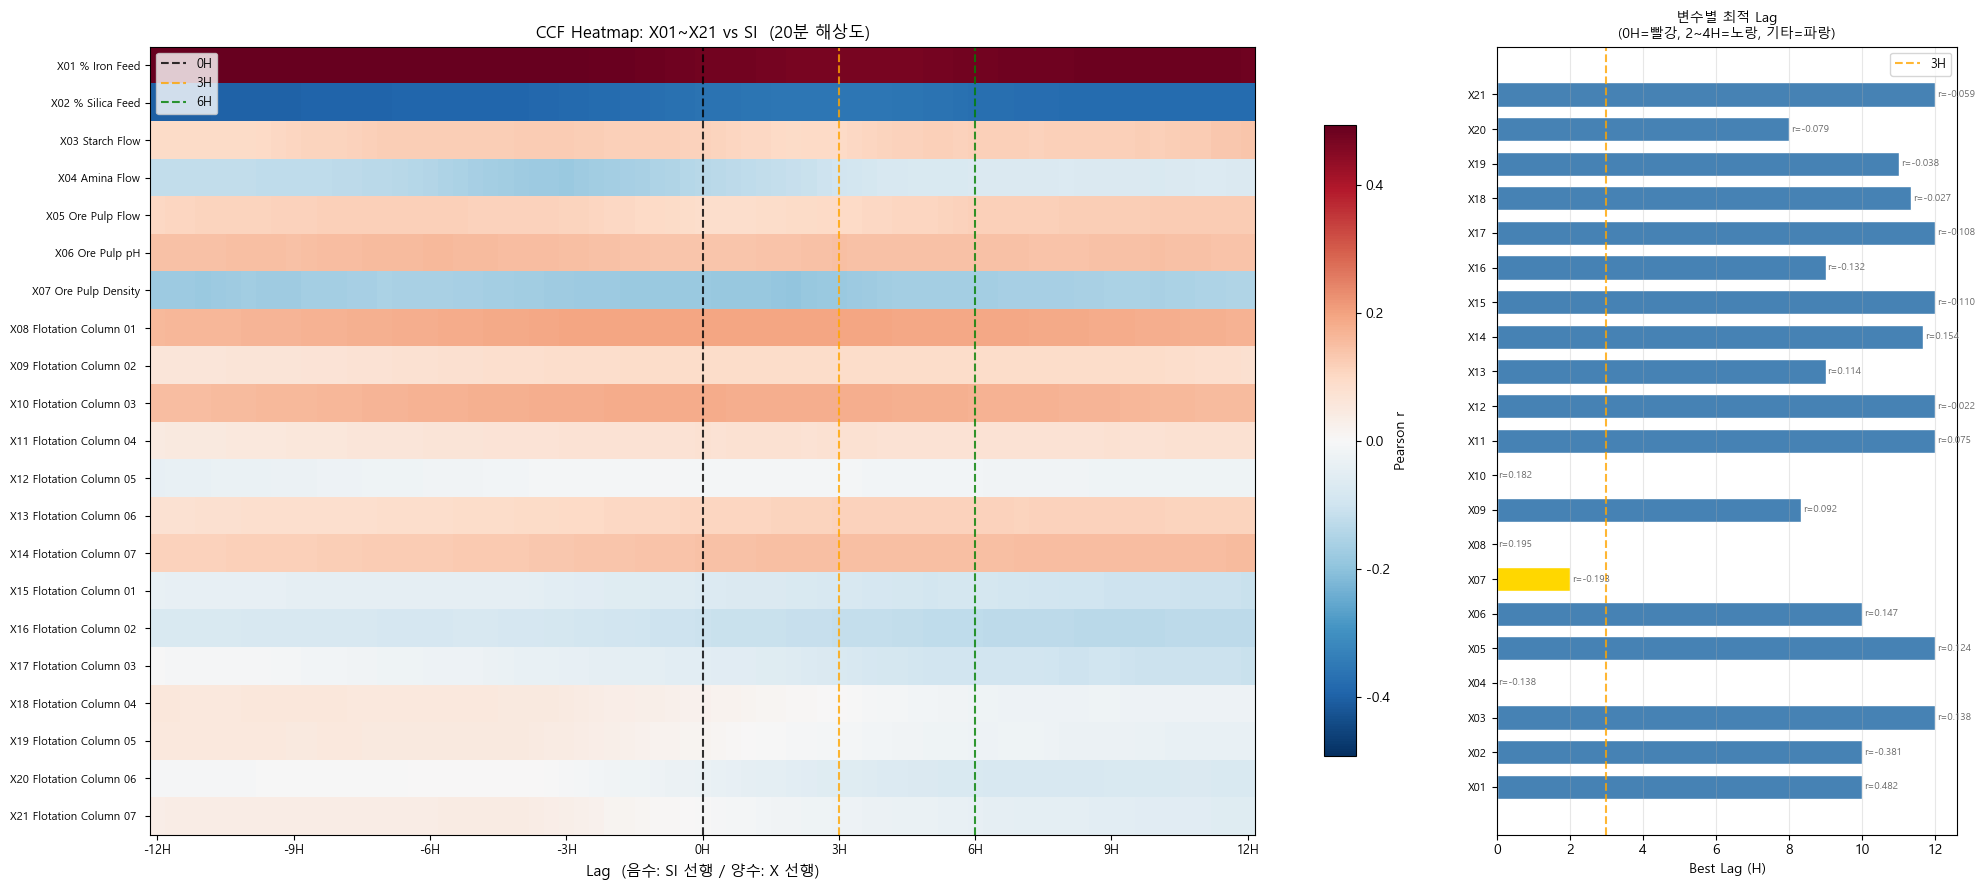

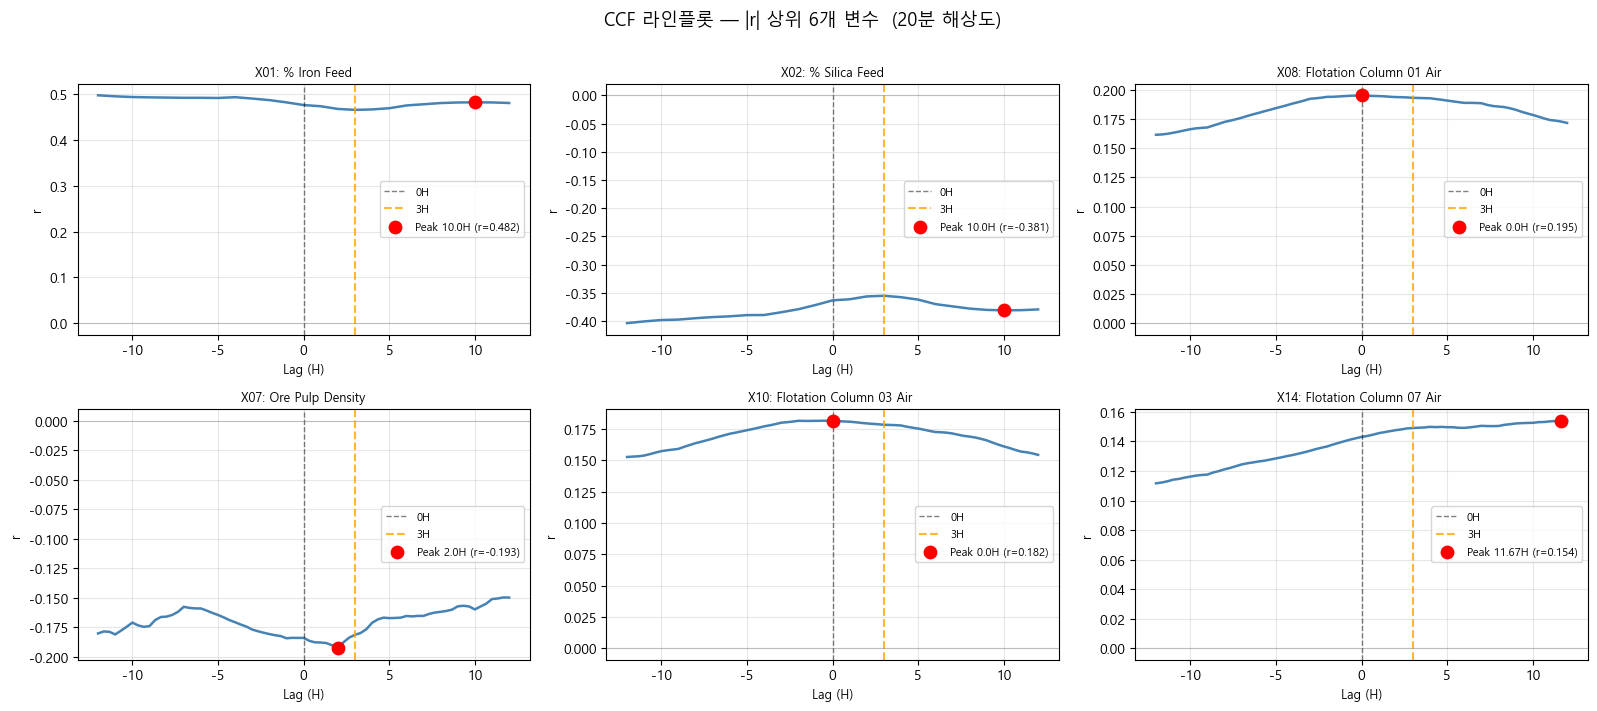

저장: ccf_20min_heatmap.png  /  ccf_20min_top6.png


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# Step 6. 시각화 — CCF 히트맵 + 상위 6개 라인플롯
# ─────────────────────────────────────────────────────────────────────────────
hour_ticks     = [steps.index(s) for s in steps if s % 9 == 0]   # 3H마다 눈금
hour_ticklabels= [f"{s/3:.0f}H" for s in steps if s % 9 == 0]

fig = plt.figure(figsize=(20, 9))
gs  = gridspec.GridSpec(1, 2, width_ratios=[3, 1], figure=fig)

# ── 히트맵 ────────────────────────────────────────────────────────────────────
ax1  = fig.add_subplot(gs[0])
vmax = np.nanpercentile(np.abs(ccf_matrix), 99)
im   = ax1.imshow(ccf_matrix, aspect="auto", cmap="RdBu_r",
                  vmin=-vmax, vmax=vmax, interpolation="nearest")
ax1.set_xticks(hour_ticks)
ax1.set_xticklabels(hour_ticklabels, fontsize=9)
ax1.set_yticks(range(len(X_LABELS)))
ax1.set_yticklabels([f"{lb} {X_COLS[i][:20]}" for i, lb in enumerate(X_LABELS)], fontsize=8)
# 수직선: 0H / 3H / 6H
for h, col, lbl in [(0, "black", "0H"), (9, "orange", "3H"), (18, "green", "6H")]:
    ax1.axvline(x=steps.index(h), color=col, lw=1.5, ls="--", alpha=0.8, label=lbl)
ax1.set_xlabel("Lag  (음수: SI 선행 / 양수: X 선행)", fontsize=11)
ax1.set_title("CCF Heatmap: X01~X21 vs SI  (20분 해상도)", fontsize=12)
plt.colorbar(im, ax=ax1, label="Pearson r", shrink=0.8)
ax1.legend(loc="upper left", fontsize=9)

# ── 최적 Lag 막대 ─────────────────────────────────────────────────────────────
ax2    = fig.add_subplot(gs[1])
colors = ["tomato" if l == 0 else ("gold" if 2 <= l <= 4 else "steelblue")
          for l in summary_df["Best Lag (H)"]]
bars   = ax2.barh(range(len(X_LABELS)), summary_df["Best Lag (H)"],
                  color=colors, edgecolor="white", height=0.7)
ax2.set_yticks(range(len(X_LABELS)))
ax2.set_yticklabels(X_LABELS, fontsize=8)
ax2.axvline(x=3, color="orange", lw=1.5, ls="--", alpha=0.8, label="3H")
ax2.set_xlabel("Best Lag (H)", fontsize=10)
ax2.set_title("변수별 최적 Lag\n(0H=빨강, 2~4H=노랑, 기타=파랑)", fontsize=10)
ax2.legend(fontsize=9); ax2.grid(axis="x", alpha=0.3)
for idx, (bar, row) in enumerate(zip(bars, summary_df.itertuples())):
    ax2.text(bar.get_width() + 0.05, idx, f"r={row.r:.3f}",
             va="center", fontsize=7, color="dimgray")

plt.tight_layout()
plt.savefig("ccf_20min_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 상위 6개 변수 라인플롯 ─────────────────────────────────────────────────────
top6 = summary_df.nlargest(6, "|r|").index.tolist()
fig2, axes2 = plt.subplots(2, 3, figsize=(16, 7))
for k, var in enumerate(top6):
    ax = axes2.flatten()[k]
    ax.plot(hours, ccf_df.loc[var].values, lw=1.8, color="steelblue")
    ax.axvline(x=0, color="black",  lw=1.0, ls="--", alpha=0.5, label="0H")
    ax.axvline(x=3, color="orange", lw=1.5, ls="--", alpha=0.8, label="3H")
    ax.axhline(y=0, color="gray",   lw=0.8, alpha=0.4)
    bl = summary_df.loc[var, "Best Lag (H)"]
    br = summary_df.loc[var, "r"]
    ax.scatter([bl], [br], s=80, color="red", zorder=5, label=f"Peak {bl}H (r={br:.3f})")
    ax.set_title(f"{var}: {X_COLS[X_LABELS.index(var)][:24]}", fontsize=9)
    ax.set_xlabel("Lag (H)", fontsize=9); ax.set_ylabel("r", fontsize=9)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle("CCF 라인플롯 — |r| 상위 6개 변수  (20분 해상도)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("ccf_20min_top6.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장: ccf_20min_heatmap.png  /  ccf_20min_top6.png")

## Step 7. Lag 비교 — Linear Regression R² (20분 해상도)

| 케이스 | 스텝 수 | 시간 |
|--------|--------|------|
| Lag 0H | 0 steps | 기준점 |
| Lag 3H | 9 steps | 논문 권장 |
| Lag 12H | 36 steps | CCF 최빈값 |
| Lag_CCF | 변수별 | 20분 CCF 최적 |

- 독립변수(X): X01~X21 (X22, X23 제외 — 데이터 누수 방지)
- 종속변수(y): SI
- 방법: 전체 데이터 In-sample Linear Regression R²

  Lag 비교 — In-sample Linear Regression R²
  (20분 해상도, X01~X21 → SI)
  Lag 0H  (0 steps)               R² = 0.4641
  Lag 3H  (9 steps)               R² = 0.4750
  Lag 12H (36 steps)              R² = 0.4211
  Lag_CCF (variable)              R² = 0.4312


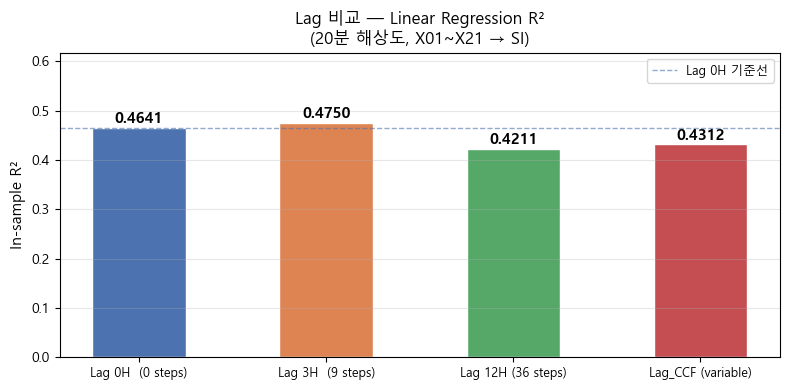

saved: lag_comparison_20min.png

[Lag_CCF 변수별 최적 스텝 분포]
    0 steps (0H    ) : 3개 변수
    6 steps (2H    ) : 1개 변수
   24 steps (8H    ) : 1개 변수
   25 steps (8H 20m) : 1개 변수
   27 steps (9H    ) : 2개 변수
   30 steps (10H   ) : 3개 변수
   33 steps (11H   ) : 1개 변수
   34 steps (11H 20m) : 1개 변수
   35 steps (11H 40m) : 1개 변수
   36 steps (12H   ) : 7개 변수


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ── X_COLS / X_LABELS 는 Step 5에서 정의됨 ────────────────────
# X_COLS  = 실제 컬럼명 리스트 (21개)
# X_LABELS= ["X01"..."X21"]
# summary_df = 변수별 Best Step (20분 단위 정수)

try:
    _ = X_COLS, X_LABELS, summary_df
except NameError:
    raise RuntimeError("Step 5(CCF) 셀을 먼저 실행하세요.")

TARGET = "SI"

# Lag_CCF: 변수별 최적 스텝 dict  {실제컬럼명: step}
lag_ccf = {
    X_COLS[i]: int(summary_df.loc[X_LABELS[i], "Best Step"])
    for i in range(len(X_COLS))
}

# ── 공통 유틸 ──────────────────────────────────────────────────
def build_XY(df, x_cols, target, lags_per_feat):
    """
    lags_per_feat: int (공통) 또는 dict {컬럼명: step}
    shift(-step): X를 미래로 당겨 현재 SI와 정렬 (X 선행 확인)
    """
    frames = {}
    for col in x_cols:
        step = lags_per_feat if isinstance(lags_per_feat, int) else lags_per_feat.get(col, 0)
        frames[col] = df[col].shift(-step)
    X_df = pd.DataFrame(frames, index=df.index)
    y_s  = df[target]
    mask = X_df.notna().all(axis=1) & y_s.notna()
    return X_df[mask].values, y_s[mask].values

def insample_r2(df, x_cols, target, lags_per_feat):
    X, y = build_XY(df, x_cols, target, lags_per_feat)
    if len(y) < 10:
        return np.nan
    model = LinearRegression().fit(X, y)
    return r2_score(y, model.predict(X))

# ── 4가지 케이스 평가 ──────────────────────────────────────────
cases = {
    "Lag 0H  (0 steps)" : 0,
    "Lag 3H  (9 steps)" : 9,
    "Lag 12H (36 steps)": 36,
    "Lag_CCF (variable)": lag_ccf,
}

print("=" * 50)
print("  Lag 비교 — In-sample Linear Regression R²")
print("  (20분 해상도, X01~X21 → SI)")
print("=" * 50)
results = {}
for name, lags in cases.items():
    r2 = insample_r2(df_20m, X_COLS, TARGET, lags)
    results[name] = r2
    print(f"  {name:30s}  R² = {r2:.4f}")
print("=" * 50)

# ── 막대 그래프 ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
names  = list(results.keys())
r2vals = [results[n] for n in names]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

bars = ax.bar(names, r2vals, color=colors, edgecolor="white", width=0.5)
ax.set_ylim(0, max(r2vals) * 1.30)
ax.set_ylabel("In-sample R²", fontsize=11)
ax.set_title("Lag 비교 — Linear Regression R²\n(20분 해상도, X01~X21 → SI)", fontsize=12)
ax.axhline(r2vals[0], color=colors[0], ls="--", lw=1.0, alpha=0.6, label="Lag 0H 기준선")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

for bar, val in zip(bars, r2vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f"{val:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.xticks(fontsize=9)
plt.tight_layout()
plt.savefig("lag_comparison_20min.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved: lag_comparison_20min.png")

# ── Lag_CCF 변수별 스텝 분포 ──────────────────────────────────
print("\n[Lag_CCF 변수별 최적 스텝 분포]")
step_dist = pd.Series(list(lag_ccf.values())).value_counts().sort_index()
for step, cnt in step_dist.items():
    h, m = divmod(step * 20, 60)
    label = f"{h}H {m}m" if m else f"{h}H"
    print(f"  {step:3d} steps ({label:6s}) : {cnt}개 변수")


step | hour  | R²
------------------------------
   0 |  0.00H | 0.4641
   1 |  0.33H | 0.4646
   2 |  0.67H | 0.4653
   3 |  1.00H | 0.4661
   4 |  1.33H | 0.4669
   5 |  1.67H | 0.4681
   6 |  2.00H | 0.4688
   7 |  2.33H | 0.4697
   8 |  2.67H | 0.4714
   9 |  3.00H | 0.4750 <-- 최대
  10 |  3.33H | 0.4726
  11 |  3.67H | 0.4705
  12 |  4.00H | 0.4688
  13 |  4.33H | 0.4644
  14 |  4.67H | 0.4604
  15 |  5.00H | 0.4570
  16 |  5.33H | 0.4535
  17 |  5.67H | 0.4500
  18 |  6.00H | 0.4467
  19 |  6.33H | 0.4439
  20 |  6.67H | 0.4412
  21 |  7.00H | 0.4382
  22 |  7.33H | 0.4355
  23 |  7.67H | 0.4332
  24 |  8.00H | 0.4311
  25 |  8.33H | 0.4285
  26 |  8.67H | 0.4260
  27 |  9.00H | 0.4241
  28 |  9.33H | 0.4242
  29 |  9.67H | 0.4236
  30 | 10.00H | 0.4227
  31 | 10.33H | 0.4220
  32 | 10.67H | 0.4218
  33 | 11.00H | 0.4214
  34 | 11.33H | 0.4208
  35 | 11.67H | 0.4204
  36 | 12.00H | 0.4211


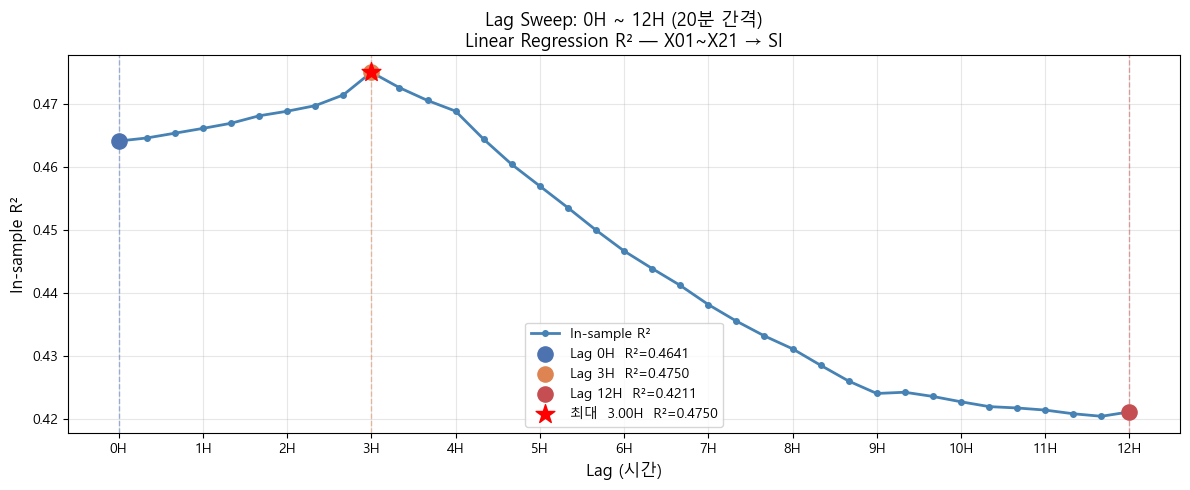


최적 Lag: 3.00H (9 steps)  R²=0.4750
saved: lag_sweep_20min.png


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# Step 8. Lag Sweep — 0~36 스텝 전체 R² 라인플롯 (20분 간격)
# ─────────────────────────────────────────────────────────────────────────────
sweep_steps = list(range(0, 37))   # 0~36 스텝 = 0H~12H
sweep_r2    = []

for step in sweep_steps:
    r2 = insample_r2(df_20m, X_COLS, TARGET, step)
    sweep_r2.append(r2)

sweep_hours = [s / 3 for s in sweep_steps]   # 시간 단위 환산

# 결과 출력
print("step | hour  | R²")
print("-" * 30)
for s, h, r in zip(sweep_steps, sweep_hours, sweep_r2):
    marker = " <-- 최대" if r == max(sweep_r2) else ""
    print(f"  {s:2d} | {h:5.2f}H | {r:.4f}{marker}")

best_step = sweep_steps[sweep_r2.index(max(sweep_r2))]
best_hour = best_step / 3

# ── 라인플롯 ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(sweep_hours, sweep_r2, color="steelblue", lw=2, marker="o",
        markersize=4, label="In-sample R²")

# 주요 포인트 강조
highlights = {0: ("Lag 0H", "#4C72B0"), 3: ("Lag 3H", "#DD8452"), 12: ("Lag 12H", "#C44E52")}
for h, (lbl, col) in highlights.items():
    idx = int(h * 3)
    ax.scatter([h], [sweep_r2[idx]], s=120, color=col, zorder=5,
               label=f"{lbl}  R²={sweep_r2[idx]:.4f}")
    ax.axvline(x=h, color=col, lw=1.0, ls="--", alpha=0.5)

# 최대값 표시
ax.scatter([best_hour], [max(sweep_r2)], s=200, color="red", marker="*",
           zorder=6, label=f"최대  {best_hour:.2f}H  R²={max(sweep_r2):.4f}")

ax.set_xlabel("Lag (시간)", fontsize=12)
ax.set_ylabel("In-sample R²", fontsize=12)
ax.set_title("Lag Sweep: 0H ~ 12H (20분 간격)\nLinear Regression R² — X01~X21 → SI", fontsize=13)
ax.set_xticks([i/3 for i in range(0, 37, 3)])
ax.set_xticklabels([f"{i//3}H" for i in range(0, 37, 3)], fontsize=10)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("lag_sweep_20min.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\n최적 Lag: {best_hour:.2f}H ({best_step} steps)  R²={max(sweep_r2):.4f}")
print("saved: lag_sweep_20min.png")
